## Paired T-Test

<b> Stephen Jay D. Paspie </b>
<br> Computer Engineering Tech. T09-A

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


Dataset: We will compare **scores before tutoring and after tutoring** using statistical hypothesis testing.

The goal of this analysis is to determine whether tutoring significantly improves student exam scores.


In [9]:
df = pd.read_csv("datasets/student_tutoring_scores.csv")

df

,Student_ID,Before_Tutoring,After_Tutoring
0,1,76.0,85.0
1,2,70.9,77.6
2,3,77.2,82.7
3,4,84.2,89.0
4,5,70.1,70.2
5,6,70.1,73.2
6,7,84.6,88.8
7,8,78.1,88.3
8,9,68.2,75.6
9,10,76.3,75.2


In [10]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Student_ID       40 non-null     int64  
 1   Before_Tutoring  40 non-null     float64
 2   After_Tutoring   40 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 1.1 KB
None
       Student_ID  Before_Tutoring  After_Tutoring
count   40.000000        40.000000       40.000000
mean    20.500000        70.245000       76.127500
std     11.690452         7.621392        7.904331
min      1.000000        56.300000       61.100000
25%     10.750000        64.500000       71.575000
50%     20.500000        70.100000       75.350000
75%     30.250000        74.625000       79.475000
max     40.000000        86.800000       99.000000


## Step 4: Data Visualization (Boxplot)


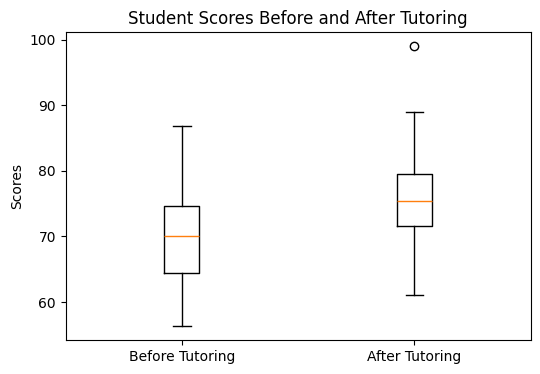

In [11]:
plt.figure(figsize=(6,4))

plt.boxplot(
    [df['Before_Tutoring'], df['After_Tutoring']],
    tick_labels=['Before Tutoring','After Tutoring']
)

plt.title("Student Scores Before and After Tutoring")
plt.ylabel("Scores")
plt.show()

Remove Outliers using the 3-Sigma Rule

In [12]:
z_before = stats.zscore(df['Before_Tutoring'])
z_after = stats.zscore(df['After_Tutoring'])

df_clean = df[(abs(z_before) < 3) & (abs(z_after) < 3)]

print("Original size:", len(df))
print("Clean size:", len(df_clean))


Original size: 40
Clean size: 40


Test for Normality

In [13]:
print("Before Tutoring Normality Test")
w1, p1 = stats.shapiro(df_clean['Before_Tutoring'])
print("W-statistic:", w1)
print("P-value:", p1)

print()

print("After Tutoring Normality Test")
w2, p2 = stats.shapiro(df_clean['After_Tutoring'])
print("W-statistic:", w2)
print("P-value:", p2)

Before Tutoring Normality Test
W-statistic: 0.9792647190867969
P-value: 0.6622477494773389

After Tutoring Normality Test
W-statistic: 0.9636077459454963
P-value: 0.22208210906902165


In [14]:
t_stat, p_value = stats.ttest_rel(
    df_clean['Before_Tutoring'],
    df_clean['After_Tutoring']
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -9.624379820136172
P-value: 7.481598392981623e-12


In [15]:
difference = df_clean['After_Tutoring'] - df_clean['Before_Tutoring']

cohens_d = difference.mean() / difference.std(ddof=1)

print("Cohen's d:", cohens_d)


Cohen's d: 1.521748064909599



 ## Conclusion

Based on the paired t-test results, we compare the p-value with the significance level (α = 0.05).

- If the p-value is **less than 0.05**, we reject the null hypothesis.
- This means tutoring has a **statistically significant effect** on student scores.

The effect size (Cohen's d) tells us how strong the improvement is.

Overall, the results suggest that **tutoring helps improve student exam performance**.
